In [4]:
import pandas as pd

df = pd.read_csv("SP 500 ESG Risk Ratings.csv")
df.isnull().sum()

,0
Symbol,0
Name,0
Address,1
Sector,1
Industry,1
Full Time Employees,5
Description,1
Total ESG Risk score,73
Environment Risk Score,73
Governance Risk Score,73


In [5]:
# Drop rows where target is missing
df = df.dropna(subset=['Total ESG Risk score'])

print("Remaining rows:", len(df))
df.isnull().sum()

Remaining rows: 430


,0
Symbol,0
Name,0
Address,0
Sector,0
Industry,0
Full Time Employees,4
Description,0
Total ESG Risk score,0
Environment Risk Score,0
Governance Risk Score,0


In [6]:
# Fix Full Time Employees — remove commas and convert to numeric
df['Full Time Employees'] = (
    df['Full Time Employees']
    .astype(str)
    .str.replace(',', '', regex=False)
)
df['Full Time Employees'] = pd.to_numeric(df['Full Time Employees'], errors='coerce')
df['Full Time Employees'] = df['Full Time Employees'].fillna(df['Full Time Employees'].median())

# Fill Controversy Score with median
df['Controversy Score'] = df['Controversy Score'].fillna(df['Controversy Score'].median())

# Verify
df.isnull().sum()

,0
Symbol,0
Name,0
Address,0
Sector,0
Industry,0
Full Time Employees,0
Description,0
Total ESG Risk score,0
Environment Risk Score,0
Governance Risk Score,0


In [7]:
from sklearn.preprocessing import LabelEncoder

le_sector = LabelEncoder()
le_controversy = LabelEncoder()

df['Sector_encoded'] = le_sector.fit_transform(df['Sector'])
df['Controversy_encoded'] = le_controversy.fit_transform(df['Controversy Level'])

# Check
df[['Sector', 'Sector_encoded', 'Controversy Level', 'Controversy_encoded']].head(10)

,Sector,Sector_encoded,Controversy Level,Controversy_encoded
1,Basic Materials,0,Moderate Controversy Level,2
2,Consumer Cyclical,2,Moderate Controversy Level,2
4,Healthcare,6,Moderate Controversy Level,2
5,Consumer Cyclical,2,Moderate Controversy Level,2
6,Healthcare,6,Moderate Controversy Level,2
7,Healthcare,6,Moderate Controversy Level,2
9,Consumer Cyclical,2,Moderate Controversy Level,2
10,Industrials,7,Low Controversy Level,1
11,Utilities,10,Moderate Controversy Level,2
12,Consumer Cyclical,2,Moderate Controversy Level,2


In [8]:
from sklearn.model_selection import train_test_split
feature_cols = [
    'Environment Risk Score',
    'Governance Risk Score',
    'Social Risk Score',
    'Controversy Score',
    'Full Time Employees',
    'Sector_encoded',
    'Controversy_encoded'
]

X = df[feature_cols]
y = df['Total ESG Risk score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (344, 7)
Testing size: (86, 7)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print("Linear Regression Results:")
print("MAE :", round(mean_absolute_error(y_test, lr_preds), 2))
print("RMSE:", round(mean_squared_error(y_test, lr_preds)**0.5, 2))
print("R²  :", round(r2_score(y_test, lr_preds), 4))

Linear Regression Results:
MAE : 0.04
RMSE: 0.06
R²  : 0.9999


In [21]:
# Coefficients tell you feature importance directly
coefficients = pd.Series(lr.coef_, index=feature_cols)
print(coefficients)

Environment Risk Score    9.998058e-01
Governance Risk Score     1.000587e+00
Social Risk Score         1.000019e+00
Controversy Score        -6.623185e-03
Full Time Employees      -1.900120e-08
Sector_encoded           -5.573444e-04
Controversy_encoded       3.041936e-03
dtype: float64


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print("Random Forest Results:")
print("MAE :", round(mean_absolute_error(y_test, rf_preds), 2))
print("RMSE:", round(mean_squared_error(y_test, rf_preds)**0.5, 2))
print("R²  :", round(r2_score(y_test, rf_preds), 4))

Random Forest Results:
MAE : 1.01
RMSE: 1.52
R²  : 0.9527


In [17]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

print("XGB Results:")
print("MAE :", round(mean_absolute_error(y_test, xgb_preds), 2))
print("RMSE:", round(mean_squared_error(y_test, xgb_preds)**0.5, 2))
print("R²  :", round(r2_score(y_test, xgb_preds), 4))

XGB Results:
MAE : 0.98
RMSE: 1.43
R²  : 0.9586


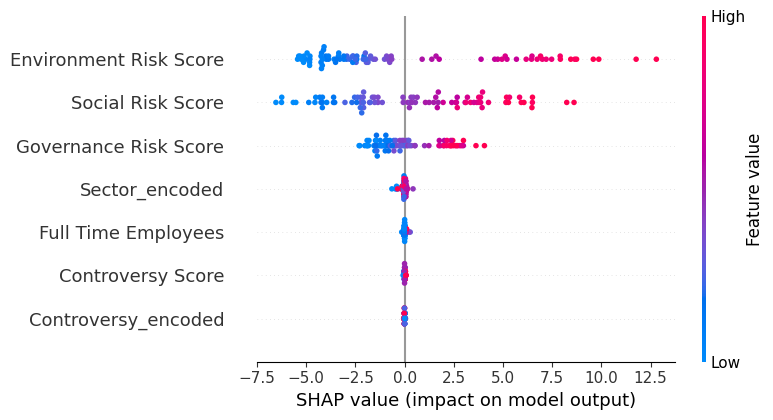

In [20]:
import shap

# Create explainer
explainer = shap.TreeExplainer(xgb, feature_perturbation="tree_path_dependent")

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Plot
shap.summary_plot(shap_values, X_test.values, feature_names=feature_cols)

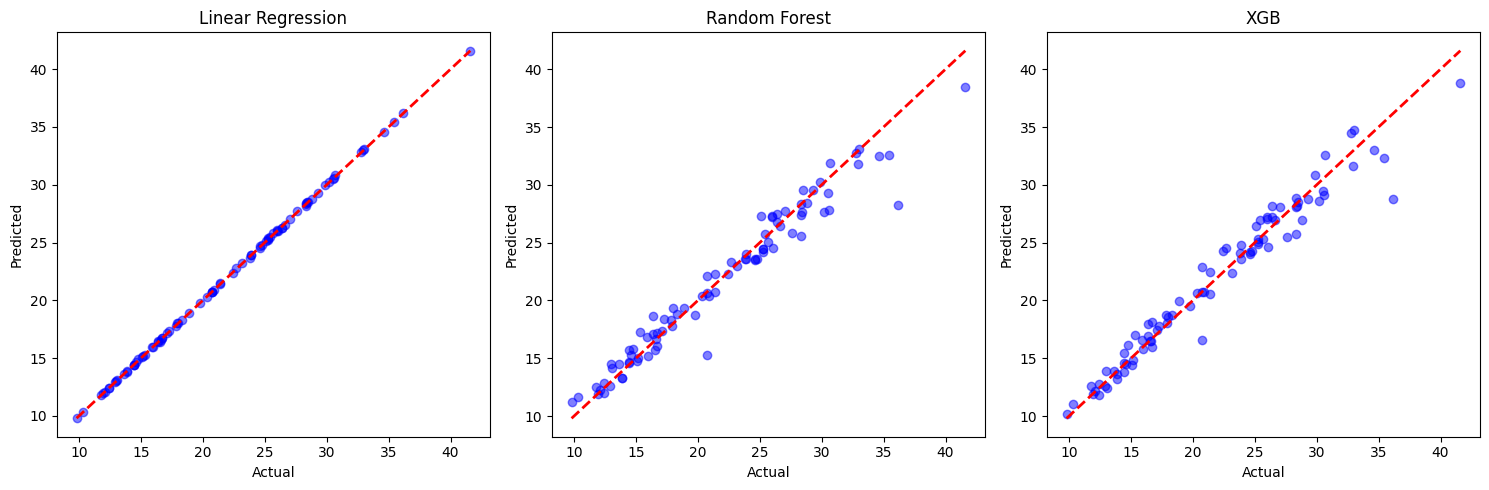

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1 - Linear Regression
axes[0].scatter(y_test, lr_preds, color='blue', alpha=0.5)
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

# Plot 2 - Random Forest
axes[1].scatter(y_test, rf_preds, color='blue', alpha=0.5)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

# Plot 3 - XGBoost
axes[2].scatter(y_test, xgb_preds, color='blue', alpha=0.5)
axes[2].set_title("XGB")
axes[2].set_xlabel("Actual")
axes[2].set_ylabel("Predicted")
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.tight_layout()
plt.show()